In [75]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore') 
print("Libraries imported.")

Libraries imported.


In [76]:
from pathlib import Path
import os

data_path = Path('Dataset') / 'flights_data_raw.csv'
print("Working directory:", os.getcwd())
print("Looking for file:", data_path.resolve())

if not data_path.exists():
    raise FileNotFoundError(f"File not found: {data_path.resolve()} - check the path or working directory.")

try:
    df = pd.read_csv(data_path)
    print("Data loaded.")
    print("First 5 rows of the dataset:")
    print(df.head())
except OSError as e:
    # common fallback: try a different encoding/engine
    print("OSError while reading CSV:", e)
    try:
        df = pd.read_csv(data_path, encoding='latin-1', engine='python')
        print("Data loaded with fallback encoding/engine.")
        print(df.head())
    except Exception as e2:
        print("Fallback failed:", e2)
        raise


Working directory: p:\flight-delay-prediction-project
Looking for file: P:\flight-delay-prediction-project\Dataset\flights_data_raw.csv
Data loaded.
First 5 rows of the dataset:
   DayOfWeek        Date  DepTime  ArrTime  CRSArrTime UniqueCarrier  \
0          4  03-01-2019     1829     1959        1925            WN   
1          4  03-01-2019     1937     2037        1940            WN   
2          4  03-01-2019     1644     1845        1725            WN   
3          4  03-01-2019     1452     1640        1625            WN   
4          4  03-01-2019     1323     1526        1510            WN   

                  Airline  FlightNum TailNum  ActualElapsedTime  ...  TaxiIn  \
0  Southwest Airlines Co.       3920  N464WN                 90  ...       3   
1  Southwest Airlines Co.        509  N763SW                240  ...       3   
2  Southwest Airlines Co.       1333  N334SW                121  ...       6   
3  Southwest Airlines Co.        675  N286WN                228  ... 

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 484551 entries, 0 to 484550
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   DayOfWeek          484551 non-null  int64
 1   Date               484551 non-null  str  
 2   DepTime            484551 non-null  int64
 3   ArrTime            484551 non-null  int64
 4   CRSArrTime         484551 non-null  int64
 5   UniqueCarrier      484551 non-null  str  
 6   Airline            484551 non-null  str  
 7   FlightNum          484551 non-null  int64
 8   TailNum            484551 non-null  str  
 9   ActualElapsedTime  484551 non-null  int64
 10  CRSElapsedTime     484551 non-null  int64
 11  AirTime            484551 non-null  int64
 12  ArrDelay           484551 non-null  int64
 13  DepDelay           484551 non-null  int64
 14  Origin             484551 non-null  str  
 15  Org_Airport        483374 non-null  str  
 16  Dest               484551 non-null  str  
 17  De

In [78]:
df.shape

(484551, 29)

In [79]:
df.sample(5)

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
16774,4,31-01-2019,1415,1600,1400,WN,Southwest Airlines Co.,1594,N642WN,105,...,9,14,0,N,0,0,0,120,0,0
42210,1,14-01-2019,1641,1836,1755,US,US Airways Inc.,490,N315AW,115,...,7,12,0,N,0,35,0,6,0,0
182993,1,10-03-2019,1504,1536,1520,WN,Southwest Airlines Co.,296,N522SW,92,...,5,6,0,N,0,12,0,0,0,4
229600,7,09-03-2019,2214,2250,2151,EV,Atlantic Southeast Airlines,4454,N882AS,36,...,2,18,0,N,0,0,0,0,0,59
51141,3,23-01-2019,1927,2048,2010,EV,Atlantic Southeast Airlines,4228,N857AS,81,...,9,15,0,N,0,0,0,0,0,38


In [80]:
df.isnull().sum()

DayOfWeek               0
Date                    0
DepTime                 0
ArrTime                 0
CRSArrTime              0
UniqueCarrier           0
Airline                 0
FlightNum               0
TailNum                 0
ActualElapsedTime       0
CRSElapsedTime          0
AirTime                 0
ArrDelay                0
DepDelay                0
Origin                  0
Org_Airport          1177
Dest                    0
Dest_Airport         1479
Distance                0
TaxiIn                  0
TaxiOut                 0
Cancelled               0
CancellationCode        0
Diverted                0
CarrierDelay            0
WeatherDelay            0
NASDelay                0
SecurityDelay           0
LateAircraftDelay       0
dtype: int64

In [81]:
#Replacing Missing values of Org_Airport and Dest_Airport with most frequent values
df['Org_Airport'] = df['Org_Airport'].fillna(df['Org_Airport'].mode()[0])
df['Dest_Airport'] = df['Dest_Airport'].fillna(df['Dest_Airport'].mode()[0])

In [82]:
df.isnull().sum()

DayOfWeek            0
Date                 0
DepTime              0
ArrTime              0
CRSArrTime           0
UniqueCarrier        0
Airline              0
FlightNum            0
TailNum              0
ActualElapsedTime    0
CRSElapsedTime       0
AirTime              0
ArrDelay             0
DepDelay             0
Origin               0
Org_Airport          0
Dest                 0
Dest_Airport         0
Distance             0
TaxiIn               0
TaxiOut              0
Cancelled            0
CancellationCode     0
Diverted             0
CarrierDelay         0
WeatherDelay         0
NASDelay             0
SecurityDelay        0
LateAircraftDelay    0
dtype: int64

In [83]:
print(df.columns)

Index(['DayOfWeek', 'Date', 'DepTime', 'ArrTime', 'CRSArrTime',
       'UniqueCarrier', 'Airline', 'FlightNum', 'TailNum', 'ActualElapsedTime',
       'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin',
       'Org_Airport', 'Dest', 'Dest_Airport', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'],
      dtype='str')


In [84]:
columns_to_drop = ['UniqueCarrier', 'FlightNum', 'TailNum', 'TaxiIn', 'TaxiOut','Cancelled', 'CancellationCode', 'Diverted']
df = df.drop(columns=columns_to_drop)

In [85]:
print(df.columns)

Index(['DayOfWeek', 'Date', 'DepTime', 'ArrTime', 'CRSArrTime', 'Airline',
       'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay',
       'DepDelay', 'Origin', 'Org_Airport', 'Dest', 'Dest_Airport', 'Distance',
       'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay',
       'LateAircraftDelay'],
      dtype='str')


In [86]:
df_balanced = df.groupby('Airline').sample(frac=0.4, random_state=42)

In [87]:
df_balanced.shape

(193820, 21)

In [88]:
df = df_balanced

In [89]:
df.sample(5)

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,Airline,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,...,Origin,Org_Airport,Dest,Dest_Airport,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
63961,2,29-01-2019,1821,1929,1725,American Eagle Airlines Inc.,128,125,101,124,...,ROC,Greater Rochester International Airport,ORD,Chicago O'Hare International Airport,528,0,0,62,0,62
245628,2,25-03-2019,1448,1727,1710,American Airlines Inc.,339,350,314,17,...,MIA,Miami International Airport,LAX,Los Angeles International Airport,2342,5,0,0,0,12
130396,3,13-02-2019,140,855,720,US Airways Inc.,255,270,229,95,...,LAS,McCarran International Airport,DCA,Ronald Reagan Washington National Airport,2089,95,0,0,0,0
299876,7,27-04-2019,1827,2125,2055,US Airways Inc.,178,160,122,30,...,PHL,Philadelphia International Airport,MCO,Orlando International Airport,861,12,0,18,0,0
255393,4,06-03-2019,1159,1747,1445,American Airlines Inc.,288,150,123,182,...,DFW,Dallas/Fort Worth International Airport,RDU,Raleigh-Durham International Airport,1062,43,0,138,0,1


In [90]:
df.drop_duplicates(inplace=True)

In [91]:
df.corr(numeric_only=True)

,DayOfWeek,DepTime,ArrTime,CRSArrTime,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
DayOfWeek,1.000000,0.017294,0.007304,0.011972,0.008208,0.012956,0.011811,-0.001130,0.004549,0.015568,0.019534,0.001942,-0.025291,0.008430,-0.001938
DepTime,0.017294,1.000000,0.362097,0.700642,-0.073582,-0.056888,-0.068074,0.104237,0.130573,-0.065321,-0.044185,-0.000466,0.002701,-0.020582,0.188154
ArrTime,0.007304,0.362097,1.000000,0.499032,-0.036210,-0.038480,-0.038985,-0.071068,-0.073524,-0.052822,-0.075205,-0.025691,0.033167,-0.011000,-0.040182
CRSArrTime,0.011972,0.700642,0.499032,1.000000,0.011185,0.024224,0.012791,0.028706,0.045336,0.013796,-0.088511,-0.019635,-0.009153,-0.017103,0.143345
ActualElapsedTime,0.008208,-0.073582,-0.036210,0.011185,1.000000,0.970044,0.975680,0.089366,0.007902,0.951035,0.029289,-0.007964,0.169165,0.002229,-0.031376
CRSElapsedTime,0.012956,-0.056888,-0.038480,0.024224,0.970044,1.000000,0.986562,0.039918,0.035497,0.983529,0.045224,-0.027264,0.046684,0.002967,-0.010797
AirTime,0.011811,-0.068074,-0.038985,0.012791,0.975680,0.986562,1.000000,0.039399,0.010356,0.977315,0.037608,-0.026301,0.068884,0.003828,-0.022086
ArrDelay,-0.001130,0.104237,-0.071068,0.028706,0.089366,0.039918,0.039399,1.000000,0.949397,0.027069,0.470913,0.273891,0.400464,-0.008335,0.502775
DepDelay,0.004549,0.130573,-0.073524,0.045336,0.007902,0.035497,0.010356,0.949397,1.000000,0.026527,0.497750,0.254128,0.243093,-0.007630,0.538781
Distance,0.015568,-0.065321,-0.052822,0.013796,0.951035,0.983529,0.977315,0.027069,0.026527,1.000000,0.046820,-0.030323,0.023205,0.003073,-0.010496


In [92]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [93]:
# Extract parts of Date
df['Month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek + 1   # Monday=1, Sunday=7
df['DayName'] = df['Date'].dt.day_name()



In [94]:
# Make a copy to be safe
df2 = df.copy()

# ---------- helper: ensure numeric where needed ----------
num_cols = ['ActualElapsedTime','Distance','ArrDelay','DepDelay',
            'CarrierDelay','WeatherDelay','NASDelay','SecurityDelay','LateAircraftDelay']

for c in num_cols:
    if c in df2.columns:
        df2[c] = pd.to_numeric(df2[c], errors='coerce')  # coerce bad values to NaN


In [95]:
# ----------  Route column = Origin + "_" + Dest ----------
if ('Origin' in df2.columns) and ('Dest' in df2.columns):
    df2['Route'] = df2['Origin'].astype(str) + '_' + df2['Dest'].astype(str)
else:
    print("Warning: 'Origin' and/or 'Dest' not in dataframe; skipping Route creation")


In [96]:
df2['LongHaul'] = (df2['Distance'] >= 1500).astype(int)

In [97]:
df2.sample(5)

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,Airline,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,...,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,Month,day,DayName,Route,LongHaul
251775,5,2019-03-22,1256,1800,1729,American Airlines Inc.,184,204,165,31,...,0,0,0,0,31,3,22,Friday,TUS_ORD,0
163123,7,2019-02-10,1509,1637,1600,American Airlines Inc.,88,95,75,37,...,17,0,0,0,20,2,10,Sunday,DFW_BHM,0
323109,4,2019-04-04,2307,101,2350,American Airlines Inc.,234,220,206,71,...,36,0,14,0,21,4,4,Thursday,DFW_SFO,0
136748,4,2019-02-21,1708,2016,1928,Delta Air Lines Inc.,128,133,97,48,...,15,0,0,0,33,2,21,Thursday,DFW_ATL,0
426586,1,2019-06-03,959,1119,1001,Skywest Airlines Inc.,80,80,75,78,...,0,0,78,0,0,6,3,Monday,SBA_SFO,0


In [98]:
columns_to_drop = ['ActualElapsedTime', 'CRSElapsedTime', 'AirTime','Origin', 'Dest',
                   'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay','LateAircraftDelay']
df2 = df2.drop(columns=columns_to_drop)

In [99]:
df2.shape

(193820, 16)

In [100]:
df2.columns

Index(['DayOfWeek', 'Date', 'DepTime', 'ArrTime', 'CRSArrTime', 'Airline',
       'ArrDelay', 'DepDelay', 'Org_Airport', 'Dest_Airport', 'Distance',
       'Month', 'day', 'DayName', 'Route', 'LongHaul'],
      dtype='str')

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import classification_report, accuracy_score, r2_score, mean_absolute_error, mean_squared_error, roc_auc_score, precision_recall_curve, f1_score
import time
import warnings
warnings.filterwarnings('ignore')


In [102]:
newdf = df2.copy()

In [103]:
cols_to_drop = [
    'ArrDelay',              # target (don’t use in X)           
    'ArrTime',               # post-flight
    'CRSArrTime'             # near target info
]

newdf = newdf.drop(columns=[c for c in cols_to_drop if c in newdf.columns])

In [104]:
y = df2['ArrDelay']   # keep original df2

In [105]:
import numpy as np

# Log distance (handles long flight effect better)
newdf['log_Distance'] = np.log1p(newdf['Distance'])

# Weekend feature
newdf['IsWeekend'] = newdf['DayOfWeek'].isin([6,7]).astype(int)

In [106]:
features = [
    'DepDelay',
    'Distance',
    'log_Distance',
    'Month',
    'DayOfWeek',
    'DepTime',
    'IsWeekend',
    'LongHaul'
]

if 'Route' in newdf.columns:
    features.append('Route')

X = newdf[features]

In [107]:
X = X.fillna(0)
y = y.fillna(0)

In [108]:
X = pd.get_dummies(X, drop_first=True)

In [109]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [110]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

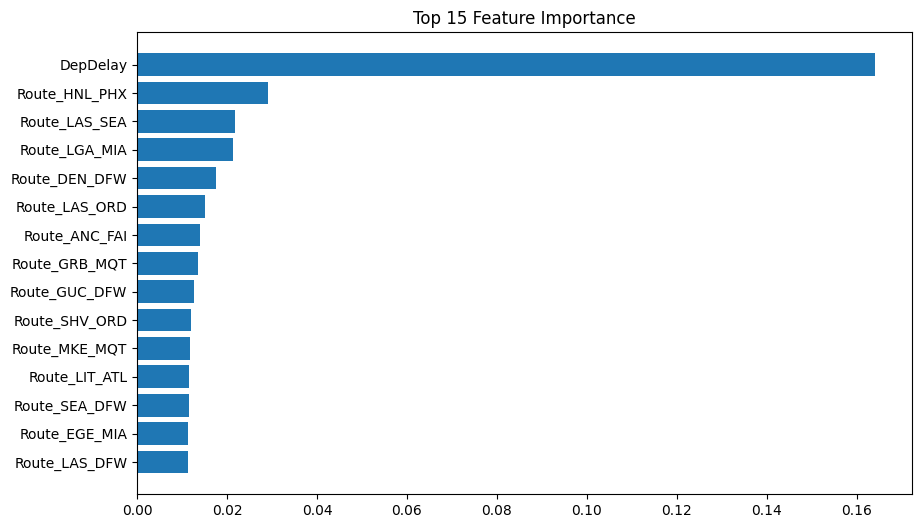

In [111]:
import matplotlib.pyplot as plt
import pandas as pd

# Get importance
importances = model.feature_importances_
features = X.columns

# Create dataframe
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': importances
})

# Sort and take top 15
feat_imp = feat_imp.sort_values(by='importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importance")
plt.show()

In [112]:
from sklearn.metrics import mean_absolute_error, r2_score

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MAE: 11.416200637817383
R2 Score: 0.8949083685874939


In [113]:
import pickle

with open('model_columns.pkl', 'wb') as f:
    pickle.dump(X.columns, f)

In [114]:
import pickle

with open('delay_minutes_model.pkl', 'wb') as f:
    pickle.dump(model, f)